### Prompt Chaining Workflow
- Fundamental and most basic sequential workflow

In [1]:
#import required libraries
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

a:\Learning_LangGraph\lg_venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
# loading the model and .env
load_dotenv()

model = ChatGroq(model = 'llama-3.3-70b-versatile')

In [ ]:
# state class for the workflow
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str

In [ ]:
#generate outline for the blog
def generate_outline(state: BlogState) -> BlogState:

    prompt = f"Generate a detailed outline for a blog post on the topic: {state['topic']}"
    outline = model.invoke(prompt).content

    state['outline'] = outline
    return state

In [ ]:
# generate the blog based on the topic and outline
def generate_blog(state: BlogState) -> BlogState:

    prompt = f"Write a blog post for the topic: {state['topic']}, based on the following outline: {state['outline']}"
    blog = model.invoke(prompt).content

    state['blog'] = blog
    return state

In [ ]:
# create a state graph and add nodes and edges
graph = StateGraph(BlogState)

#nodes
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)

#edges
graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog', END)

#compile graph into a workflow
work_flow = graph.compile()

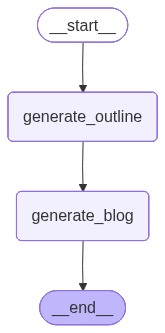

In [ ]:
# visualize the workflow
from IPython.display import Image
Image(work_flow.get_graph().draw_mermaid_png())

In [20]:
#execute the workflow
initial_state = {'topic' : "The impact of Artificial Intelligence on the job market."}
final_state = work_flow.invoke(initial_state)
print(final_state['topic'])

The impact of Artificial Intelligence on the job market.


In [21]:
print(final_state['outline'])

Here's a detailed outline for a blog post on the impact of Artificial Intelligence (AI) on the job market:

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its increasing presence in various industries
* Importance of understanding the impact of AI on the job market
* Thesis statement: While AI has the potential to bring about significant benefits, it also poses significant challenges to the job market, and it's essential to explore its impact to prepare for the future.

**II. Current State of AI in the Job Market**

* Overview of the current applications of AI in various industries, such as:
	+ Manufacturing and automation
	+ Customer service and chatbots
	+ Data analysis and predictive modeling
	+ Healthcare and medical research
* Statistics on the growing adoption of AI in businesses and organizations

**III. Positive Impact of AI on the Job Market**

* Creation of new job opportunities in fields related to AI development and implementation
* Increased prod

In [22]:
print(final_state['blog'])

**The Impact of Artificial Intelligence on the Job Market: Opportunities and Challenges**

Artificial Intelligence (AI) is no longer a futuristic concept, but a reality that is increasingly present in various industries. From manufacturing and automation to customer service and healthcare, AI is transforming the way businesses operate and interact with their customers. As AI continues to advance and become more pervasive, it is essential to understand its impact on the job market. While AI has the potential to bring about significant benefits, it also poses significant challenges to the job market, and it's essential to explore its impact to prepare for the future.

**Current State of AI in the Job Market**

AI is currently being applied in various industries, including manufacturing and automation, customer service and chatbots, data analysis and predictive modeling, and healthcare and medical research. According to a recent survey, 61% of businesses have already implemented AI in som